# Regression Disconuity Design - Incumbency Advantage In US Elections

In this notebook I will explain and evaluate regression discontinuity designs for estimating causal effects. To do this I will be replicating a study by Lee (2008). 

Regression discontinuity designs (RDDs) exploit natural experiments in the environment. They rely on the fact that a treatment is performed upon a unit when the attribute of a unit crosses a certain threshold. It is assumed that close to either side of the threshold units are similar with the only difference being whether they received the treatment or not. Therefore, the difference in some variables of interest between the groups close to threshold is the causal effect of the treatment. It can be show that with some reasonable assumption RDD can be as reliable as randomised controlled trials (Lee 2008). How amazing! We can get results as good as RCTs by exploiting some fact about our enviroment. However, a note of caution, for the RDD estimate to be non-biased some assumptions must be true (all of which are not testable) and furthermore, we must interpret the result correctly (see the assumptions and implementation sections below) 

In this notebook we apply RDDs to studying the incumbency advantage. By incumbency advantage we mean the fact that incumbents in the US House Representatives are much more likely to be relected. Lee (2008) states that the relection rate of incumbents is about 90% and has been stable over the last 50 years. RDDs can be applied to study the incumbency advantage because we know the threshold at which a candidate recieves the treatment of being an incumbent, it is when vote count is 50%. Therefore, if the assumptions of RDD hold, then the difference in votes received at the next election by incumbents who just won their district vs candidates who just lost their district in the previous election will give the causal effect of incumbency on vote share received.

Some quick notation for the rest of the notebook. Each inidividual $i$ has vote share at the next election of $Y$, if they are the incumbent they receive $Y^{1}$ if not they recieve $Y^{0}$. Each individual also has a set of covariates $X_{i}$ which contains the *running variable* $V_{i}$ (last election vote share in this context), when $V_{i} > v_{0}$ (last election vote share is greater than 0.5) the individual recieves the treatment (becomes the incumbent).


# Assumptions of RDD

**Needs more work**


RDDs assume the following (Lemieux & Imbens 2008):

1. $E[Y^{0} | V=v] \text{ and } E[Y^{1} | V=v] \text{ are continous in } v$

2. $F_{Y^{0} | v}(y|v) \text{ and } F_{Y^{1} | v}(y|v) \text{ are continuous in } c$

These assumptions are actually stronger than required as actually we only require continuity at the threshold value $V=v_{0}$. If these assumptions are true they are telling us the individuals just below the threshold are a good counterfactual for individuals just above the threshold. For example, looking at assumption 1, If the conditional expectation of $Y_{0}|V$ is continuous (especially at the threshold) it means we can assume if the individuals who did not recieve the treatment scored just above $v_{0}$ and still did not recieve the treatment their outcome would not change much (only by $\frac{dY^{0}|V}{dV}$) and therefore, we assume this is what individuals who score just above threshold would have obtained had they not recieved the treatment.

**Important** Notice that there is however a problem here. What does it mean for an individual to get more than 50% of the vote and not be elected? There is no reality where this happens. The potential outcomes framework does not allow us to describe this design very logically. Lee (2008) actually changes the assumptions slightly. We drop the potential outcomes notation assume that the outcome is a function of the attributes of each unit and the treatment. The outcome must be continuous in the treatment, except at the discontinuity. Further, the distribution of the running variable conditional on the covariates is continuous at $v_{0}$. Again this is just to make sure that either side of the discontinuity can be considered reasonable counterfactuals for each other. Mathematically if the assumptions hold we have,

$$
\int^{\infty}_{-\infty}(y^{+}(x) - y^{-}(x)\frac{f(0|x)}{f(0)}dG(w))
$$
$$
= ATE^{**}
$$

$ATE^{**}$ is the weighted average of individual-specific discontinuity gaps (Lee 2008).

We should also assume that around the threshold there is at least some random element determining if an individual wins the election or not. For example, even though to some extent the individual can control the vote share they receive through campaign policies, hown they present themselves etc, they cannot control the weather and this can affect who turns out to vote. If individuals had full control over the vote share they received then individuals below the threshold would be qualitatively different to those above the treatment and would not be a good counterfactual for them. Furthermore, if there is randomisation around the threshold then we essentially have a randomised experiment around the threshold and we can expect that the treatment will be independent of the covariates (testable assumption) and the outcome will be independent of the covariates (another testable assumption)

# Implementation and Interpretation of RDD

**What are we trying to estimate** 

When implementing an RDD we are trying to estimate $E[Y^{1} | V=v_{0}] - E[Y^{0} | V=v_{0}]$. However, there are no examples of $Y^{0}$ at $V=v_{0}$. Therefore, in practice we take a bandwith $b$ from the threshold value $v_{0}$ and fit a regression on each dataset. So this means we have two datasets, $v_{0} - b \le v \lt v_{0}$ and  $v_{0} \le v \le v_{0} + b$

We must be careful in interpretting the estimate of an RDD. It is not the ATE, for example it does not tell us how much vote share a candidate who achieved 10% of the vote would achieve had they been the incumbent. These candidates are qualitatively different to those candidates who get elected and incumbency probably would not be such an advantage to them. It tells us the treatment effect at the discontinuity.

We can check the robustness of our RDDs. For example we can check if:

1. Including other covariates changes the estimates - it shouldn't because we assume at the discontinuity the candidates are as good as randomised into the treatment
2. (Similar to the above) the distribution of covariates are identical just above and below discontinuity
3. Mcgreary test - tests if candidates can self select into treatment


In [48]:
import pandas as pd
import matplotlib.pyplot as plt
from lee_data import get_data
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Load Data

Data on US congressional elections between 1946-1998 are used. The dataset contains the following columns

- *yearel* - election year
- *myoutcome* - the democrat candidate won
- *second* - the democrat candidate was second
- *myoutcomenext* - the democrat candidate won the following election
- *use* -
- *difshare* - the percentage points more votes won by the democrat than the next best candidate
- *difgrp* -
- *mmyoutcomenext* - the percent of the vote won by democrat candidate at the next election
- *mrunagain* - 
- *mofficeexp* - 
- *melectexp* -



In [18]:
df = get_data("individ_final.dta")
df.head()

,yearel,myoutcome,second,myoutcomenext,use,difshare,difgrp,mmyoutcomenext,mrunagain,mofficeexp,melectexp,mpmyoutcomenext,mprunagain,mpofficeexp,mpelectexp
0,1946.0,1.0,NaN,0.0,NaN,0.061488,212.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1946.0,0.0,1.0,0.0,1.0,-0.061488,187.0,0.107143,0.214286,2.053571,2.339286,0.069917,0.285555,0.671483,0.932918
2,1948.0,1.0,NaN,1.0,1.0,0.104869,220.0,0.743590,0.871795,3.256410,3.461539,0.749363,0.869388,2.650860,2.872225
3,1948.0,0.0,1.0,0.0,NaN,-0.104869,179.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1948.0,0.0,NaN,0.0,NaN,-0.535721,92.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# Visualise the discontinuity

The scatter plot below clearly visualises the discontinuity in vote share at the next election between candidates who won the previous election (to the right of the black line) and candidates who lost the previous election (to the left of the black line)



Text(0.5, 1.0, 'Incumbency Advantage in US Elections')

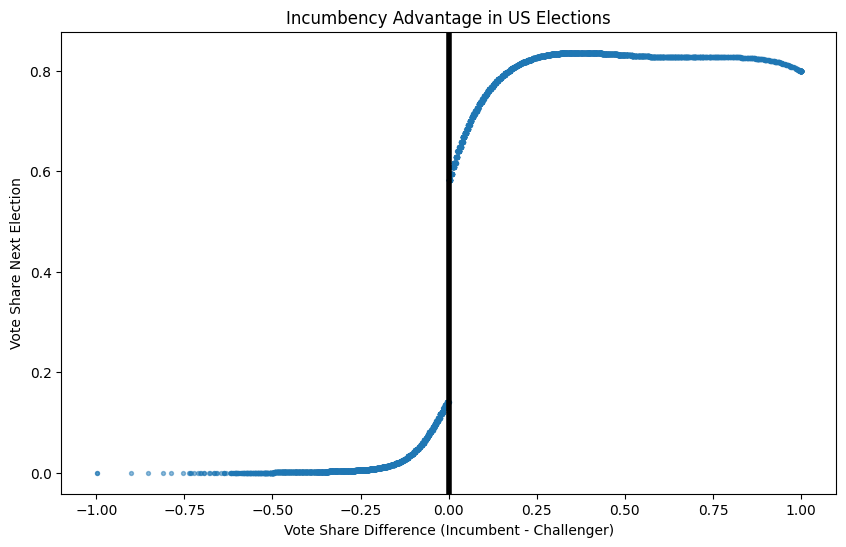

In [33]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(df['difshare'], df['mpmyoutcomenext'], alpha=0.5, s=8)
ax.axvline(0, color='black', lw=4)
ax.set_xlabel('Vote Share Difference (Incumbent - Challenger)')
ax.set_ylabel('Vote Share Next Election')
ax.set_title('Incumbency Advantage in US Elections')


# Naive Mean Difference Estimator

Why don't we just compute the difference between average vote share obtained by incumbents against the same value for non-incumbents and call this the incumbency advantage? Well as we can see in the scatter plot above, *vote share* is positive correlated with *vote share at the next election* either side of the discontinuity. This means we would expect a candidate to better at the next election if their vote share was higher than another candidate even if they both lost or both won the election - that is, we have selection bias.

**maybe expand on this**

The naive mean estimator of the causal impact of incumbency of $77%$. As shown below, this is large overestimate of the true effect due to the selection bias

In [37]:
print(df[df['difshare'] >= 0]['mpmyoutcomenext'].mean() - df[df['difshare'] < 0]['mpmyoutcomenext'].mean())

0.7695325


# Regression Discontinuity

Implement RDD 

Discuss the results

## 1. Simple Linear Regression

In [40]:
df_clean = df.dropna(subset=['difshare', 'mpmyoutcomenext'])

In [81]:
bandwidth = 0.05

In [82]:
above_threshold_condition = (df_clean['difshare'] >= 0) & (df_clean['difshare'] < bandwidth)
below_threshold_condition = (df_clean['difshare'] < 0) & (df_clean['difshare'] > -bandwidth)

In [83]:
reg_1 = LinearRegression()
reg_1.fit(df_clean[above_threshold_condition][['difshare']], df_clean[above_threshold_condition]['mpmyoutcomenext'])

reg_2 = LinearRegression()
reg_2.fit(df_clean[below_threshold_condition][['difshare']], df_clean[below_threshold_condition]['mpmyoutcomenext'])

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [84]:
estimate = reg_1.intercept_ - reg_2.intercept_
print(f"Estimated Incumbency Advantage: {estimate:.4f}")

Estimated Incumbency Advantage: 0.4381


## 2. High Order Polynomial fit

**why do we need to do this**

In [105]:
poly = PolynomialFeatures(degree=2)

reg_3 = LinearRegression()
reg_3.fit(poly.fit_transform(df_clean[above_threshold_condition][['difshare']]), df_clean[above_threshold_condition]['mpmyoutcomenext'])

reg_4 = LinearRegression()
reg_4.fit(poly.fit_transform(df_clean[below_threshold_condition][['difshare']]), df_clean[below_threshold_condition]['mpmyoutcomenext'])


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [106]:
estimated_effect = reg_3.intercept_ - reg_4.intercept_
print(f"Estimated Incumbency Advantage (Polynomial): {estimated_effect:.4f}")

Estimated Incumbency Advantage (Polynomial): 0.4344


# Robustness Checks

# Bibliography

Lee 2008